# Derivative Pricing
## Introduction
Two common methods of pricing financial derivatives are analytical formulas and Monte Carlo simulations. Analytical formulas begin from a model of the underlying asset, and result in a formula for the fair price of the derivative. This has the advantage that it can also be used to determine the replicating portfolio of the derivative, but it has the drawback that such analytical formulas are not available for all derivatives. American put options and Asian options with arithmetic averaging, for instance, lack such closed-form formulas (although approximations may exist), showing the usefulness of Monte Carlo simulation in derivative pricing. Monte Carlo methods work by simulating a large number of price processes for the underlying asset, and estimating the fair value of the derivative based on the average discounted value of the resulting derivative payoffs. While it can be used in cases where there is no analytical solution, Monte Carlo methods come at the cost of approximation error and computational complexity.

To illustrate the complementary usefulness of analytical and Monte Carlo methods in derivative pricing, this project will consider three different derivatives:
* Firstly, we consider a "power payoff" derivative which has an analytical price and replicating portfolio. We derive this price, compare it to the Monte Carlo estimate of the price, and implement the replicating portfolio as well as transaction costs.
* Secondly, we consider an Asian option with arithmetic averaging, which has no analytical price, so Monte Carlo methods are used for pricing. This price is compared to that of an Asian option with geometric averaging, which provides a lower bound on the price of the arithmetic Asian option.
* Thirdly, we consider an American put option, which likewise has no analytical price. We approximate the price, as well as the optimal exercise boundary, using the binomial model, the Longstaff-Schwartz model, and the Barone-Adesi-Whaley approximation.

## Derivative 1: The Power Payoff
### Price and Replicating Portfolio Derivation
Consider the case of the (perhaps unusual) derivative given by $X = (S_{T})^{K}$, where $S_t$ denotes the stock price at time $t$,  $K$ is a contant such that $K>1$, and the derivative matures at time $T$. This derivative $X$ can be replicated (hedged) by trading the underlying stock and zero-coupon bonds with face value 1 and maturity at time $T$. We begin by deriving this replicating portfolio of the derivative $X$.

The replicating portfolio of the derivative is given by $V_t = w_t^B B_t + w_t^S S_t$, where $w_t^B$ and $w_t^S$ are the number of bonds and stocks, respectively, held at time $t$. Assume the dynamics of the bond and stock, respectively, are given by $dB_t = r B_tdt$, and $dS_t = μ S_t dt + σ S_t dW_t$, where $W_t$ is Brownian, as in the Black-Scholes market model. Then the dynamics of $V_t$ are given by

$$
dV_t = w_t^B dB_t + w_t^S dS_t = w_t^B r B_tdt + w_t^S dS_t
$$

The replicating portfolio has the same value as the arbitrage-free value of the derivative at any time $t$, so $V_t = F_t$ for all $t\in[0, T]$, where the arbitrage-free price of the derivative at time $t$ is given by

$$
F_t = e^{-r(T-t)}𝔼^\mathbb{Q}((S_{T})^{K})
$$

$𝔼^\mathbb{Q}$ denotes the expected value taken under the probability measure $\mathbb{Q}$, where $\mathbb{Q}$ is the probability measure equivalent to the real-world probability measure under which it holds that the discounted stock price $\tilde{S_t} = S_t / B_t$ is a martingale. The dynamics of the discounted stock price is given by

$$
\begin{aligned}
d\tilde{S_t}
&= d(\frac{S_t}{B_t}) \\[6pt]
&= \frac{1}{B_t} dS_t - \frac{S_t}{B_t^2}dB_t \\[6pt]
&= \frac{S_t}{B_t}(μ dt + σ dW_t) - \frac{S_t}{B_t}(r dt) \\[6pt]
&= \frac{S_t}{B_t} ((μ - r) dt + σ dW_t)
\end{aligned}
$$


For $\tilde{S_t}$ to be a martingale under $\mathbb{Q}$, it needs to have zero drift. By Girsanov's theorem, if we set $ϕ = \frac{μ - r}{σ}$, then $dW_t = dW_t^\mathbb{Q} - ϕ dt$, where $W_t^\mathbb{Q}$ is Brownian under the probability measure $\mathbb{Q}$ defined by the Radon-Nikodym derivative

$$
\frac{d\mathbb{Q}}{d\mathbb{P}} = \exp\left( -\frac{1}{2}\int_0^T ϕ^2 \, dt - \int_0^T ϕ \, dW_t \right)
$$

Using this relation, we can now compute the dynamics of the stock

$$
\begin{aligned}
dS_t
&= μ S_t dt + σ S_t dW_t \\[6pt]
&= μ S_t dt + σ S_t (dW_t^\mathbb{Q} - ϕ dt) \\[6pt]
&= μ S_t dt + σ S_t (dW_t^\mathbb{Q} - \frac{μ - r}{σ} dt) \\[6pt]
&= r S_t dt + σ S_t dW_t^\mathbb{Q}
\end{aligned}
$$

Now, since $V_t = F_t$, we get that $dV_t = dF_t$. The dynamics of $F_t$ are given by Itô's lemma:

$$
\begin{aligned}
dF_t
&= \frac{\partial F_t}{\partial t}\,dt
+ \frac{\partial F_t}{\partial S_t}\,dS_t
+ \tfrac{1}{2}\frac{\partial^2 F_t}{\partial S_t^2}\,(dS_t)^2 \\[6pt]
&= \frac{\partial F_t}{\partial t}\,dt
+ \frac{\partial F_t}{\partial S_t}\,dS_t
+ \tfrac{\sigma^2}{2}\frac{\partial^2 F_t}{\partial S_t^2}\, S_t^2\,dt \\[6pt]
&= \left(\frac{\partial F_t}{\partial t}
+ \tfrac{\sigma^2}{2} S_t^2 \frac{\partial^2 F_t}{\partial S_t^2}\right) dt
+ \frac{\partial F_t}{\partial S_t}\,dS_t
\end{aligned}
$$

Setting this equal to the dynamics of the replicating portfolio, $dV_t = w_t^B r B_tdt + w_t^S dS_t$, and solving for $w_t^B$ and $w_t^S$, we get that

$$
w_t^S = \frac{\partial F_t}{\partial S_t},
\quad
w_t^B = \frac{1}{r B_t}
\left(
\frac{\partial F_t}{\partial t}
+ \tfrac{\sigma^2}{2} S_t^2 \frac{\partial^2 F_t}{\partial S_t^2}
\right).
$$

In this case,
$$
\begin{aligned}
F_t
&= e^{-r(T-t)}\,\mathbb{E}^\mathbb{Q}\!\left[(S_T)^{K}\right] \\[6pt]
&= e^{-r(T-t)}\,\mathbb{E}^\mathbb{Q}\!\left[S_t^K
\exp\!\Big(K\!\big(r-\tfrac{\sigma^2}{2}\big)(T-t) + K\sigma(W_T^\mathbb{Q} - W_t^\mathbb{Q})\Big)\right] \\[6pt]
&= e^{-r(T-t)}\,S_t^K
\exp\!\Big(K\!\big(r-\tfrac{\sigma^2}{2}\big)(T-t)\Big)
\mathbb{E}^\mathbb{Q}\!\left[\exp\!\big(K\sigma(W_T^\mathbb{Q} - W_t^\mathbb{Q})\big)\right] \\[6pt]
&= e^{-r(T-t)}\,S_t^K
\exp\!\Big(K\!\big(r-\tfrac{\sigma^2}{2}\big)(T-t)\Big)
\exp\!\Big(\tfrac{1}{2}K^2\sigma^2(T-t)\Big) \\[6pt]
&= S_t^K\,\exp\!\Big(\big((K-1)r + \tfrac{1}{2}\sigma^2(K^2-K)\big)(T-t)\Big)
\end{aligned}
$$

Therefore, the partial derivatives become

$$
\begin{aligned}
\frac{\partial F}{\partial S_t}
&= K S_t^{\,K-1}\exp\!\Big(\big((K-1)r + \tfrac{1}{2}\sigma^2(K^2-K)\big)(T-t)\Big)\\[6pt]
\frac{\partial^2 F}{\partial S_t^2}
&= K(K-1) S_t^{\,K-2}\exp\!\Big(\big((K-1)r + \tfrac{1}{2}\sigma^2(K^2-K)\big)(T-t)\Big)\\[6pt]
\frac{\partial F}{\partial t}
&= \big((1-K)r + \tfrac{1}{2}\sigma^2(K-K^2)\big) S_t^K \exp\!\Big(\big((K-1)r + \tfrac{1}{2}\sigma^2(K^2-K)\big)(T-t)\Big)\\[6pt]
\end{aligned}
$$

Finally, after cancelling terms, we find that, since $B_t = e^{rt}$, the  weights of the **replicating portfolio** are given by
$$
\boxed{\displaystyle
w_t^S = K S_t^{\,K-1}\exp\!\Big(\big((K-1)r + \tfrac{1}{2}\sigma^2(K^2-K)\big)(T-t)\Big)\\[6pt]
w_t^B = \exp(-rt)(1-K)S_t^K \exp\!\Big(\big((K-1)r + \tfrac{1}{2}\sigma^2(K^2-K)\big)(T-t)\Big)\\[6pt]
}
$$

This is the ideal weights at any time, but as we can only rebalance the portfolio finitely many times, we will not be able to take these positions exactly. Therefore, the bond position will in practice be given by $w_t^B = \big(V_t - w_t^SS_t \big)/B_t$ in all time steps but the first.

Additionally, as shown above, the fair **price** of the derivative at time $t$ is given by
$$
\boxed{\displaystyle
F_t = S_t^K\,\exp\!\Big(\big((K-1)r + \tfrac{1}{2}\sigma^2(K^2-K)\big)(T-t)\Big)
}
$$
### Analytical Price and Monte Carlo Estimates
To show the validity of the formula above, we now compare it to the Monte Carlo simulation of the derivative's price, setting $t=0$ in order to get the current price of the derivative. As
$$
dS_t = r S_t dt + σ S_t dW_t^\mathbb{Q}
$$
it holds that
$$
S_T = S_t * \exp((r-\tfrac{1}{2}\sigma^2)(T-t) + \sigma (W_T^\mathbb{Q} - W_t^\mathbb{Q}))
$$
which at $t=0$ becomes
$$
S_T = S_0 * \exp((r-\tfrac{1}{2}\sigma^2)T + \sigma W_T^\mathbb{Q})
$$


and the fair value of the derivative at $t=0$ is
$$
F_0 = \exp(-rT) * \mathbb{E}^\mathbb{Q}(S_T^K)
$$


The random variable $W_T^\mathbb{Q}$ can be partitioned into intervals which are independent and normally distributed under $\mathbb{Q}$. By dividing the time to maturity into $n$ equally long increments of length $Δt = \tfrac{T}{n}$, each increment is distributed as $σ \sqrt{Δt} N(0,1)$, allowing us to simulate the price paths of the derivative by simulating standard normal random variables using Monte Carlo simulation. By repeating this simulation a large number ($N$) of times, taking the average payoff, and then discounting the payoff to the present, we get the Monte Carlo simulation of the derivative's fair price.

The error of the Monte Carlo estimate depends on the number of simulations used; here we will investigate the relationship between the number of simulations used and the root mean squared error (RMSE) of the Monte Carlo simulation. To do this, for various values of $N$,  simulate the price using this value, and calculate the error in each simulation, and take the average error (here, the RMSE) for each value of N.

To see what the expected relationship between $N$ and RMSE is, we begin by utilizing the fact that the mean squaured error (MSE) can be expressed in terms of the variance and bias:

$$
\mathrm{MSE(\hat{P_N})} = V(\hat{P_N}) + Bias(\hat{P_N})^2
$$
where $\hat{P_N}$ is the Monte Carlo estimate of the fair value of the derivaive when $N$ simulations are used, and the bias is the difference between the expected value of the $\hat{P_N}$ estimator and the true (analytical) price of the option. Since the Monte Carlo estimate of the price is unbiased, the MSE is equal to the variance of the estimator, which is given by

$$
\begin{aligned}
V(\hat{P_N})
&= V\Big(\frac{1}{N}\sum_{i=1}^{N} X_i\Big) \\
&= \frac{1}{N^2}\sum_{i=1}^{N}V(X_i) \\
&= \frac{1}{N^2} N σ^2 \\
&= \frac{σ^2}{N}
\end{aligned}
$$

Hence, we see that the variance, and consequencly the MSE, is inversely proportional to $N$, so RMSE is proportional to $N^{-1/2}$, and we expect the errors shown in the log-log plot to decrease as N increases, with a slope of $-1/2$


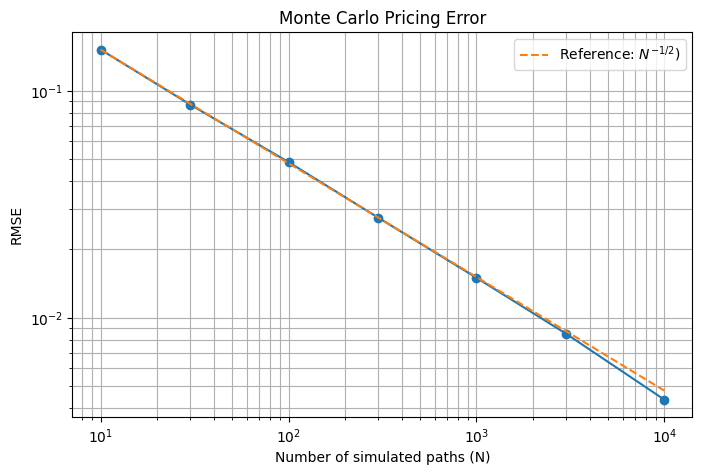

Empirical slope of errors of Monte Carlo simulations: -0.510


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
np.random.seed(111)

#Example values of constants
S0 = 1
K = 2
sigma = 0.2
r = 0.05
mu = 0.2
T = 1

def analytical_derivative_price_1(S0, K, sigma, r, T):
    return S0**K * math.exp(((K - 1) * r + 0.5 * sigma**2 * (K**2 - K))* T)

def monte_carlo_derivative_price_1(S0, K, sigma, r, T, N, n):
    dt = T / n
    Z = np.random.normal(size=(N, n))
    paths = np.zeros((N, n + 1))
    paths[:, 0] = S0
    for i in range(n):
        paths[:, i + 1] = paths[:, i] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, i])
    payoffs = paths[:, -1]**K
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

def analyze_mc_error_1(S0, K, sigma, r, T, n, N_values, repetitions, analytical_price):
    rmse_values = []
    for N in N_values:
        errors = []
        for _ in range(repetitions):
            mc_price = monte_carlo_derivative_price_1(S0, K, sigma, r, T, N, n)
            error = mc_price - analytical_price
            errors.append(error)
        errors = np.array(errors)
        rmse_values.append(np.sqrt(np.mean(errors**2)))
    N_values = np.array(N_values)
    rmse_values = np.array(rmse_values)
    reference_line = rmse_values[0] * np.sqrt(N_values[0] / N_values)

    log_N = np.log(N_values)
    log_RMSE = np.log(rmse_values)
    empirical_slope, _ = np.polyfit(log_N, log_RMSE, 1)

    plt.figure(figsize=(8, 5))
    plt.loglog(N_values, rmse_values, marker="o")
    plt.loglog(N_values, reference_line, linestyle="--", label=r"Reference: $N^{-1/2}$)")
    plt.xlabel("Number of simulated paths (N)")
    plt.ylabel("RMSE")
    plt.title("Monte Carlo Pricing Error")
    plt.legend()
    plt.grid(True, which="both")
    plt.show()
    print(f"Empirical slope of errors of Monte Carlo simulations: {empirical_slope:.3f}")

analyze_mc_error_1(S0, K, sigma, r, T, 1000, [10, 30, 100, 300, 1000, 3000, 10000], 100, analytical_derivative_price_1(S0, K, sigma, r, T))

Above we see that the empirical slope of the errors of the Monte Carlo simulation follow the theoreticlly expected relationship closely. This relationship demonstrates one of the drawbacks of the Monte Carlo method of derivative pricing: in order for the simulation to give accurate results, a larger number of simulations must be carried out.

### Replicating Portfolio
The replicating portfolio is implemented below, by first simulating paths of the stock price under the specified model, and then constructing the  portfolio at a number of time steps. The option price and the price of the replicating portfolio over time are shown in the first graph, as well as the value of the stock underlying the option. The overlap between the replicating portfolio and the value of the derivative demonstrate that the portfolio does indeed manage to replicate the derivative. The second graph shows the (possibly negative) number of stocks and bonds held at each time point, showing the composition of the underlying portfolio.

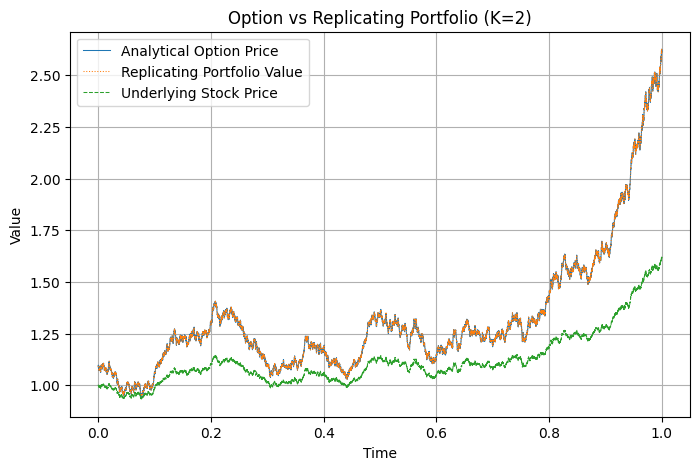

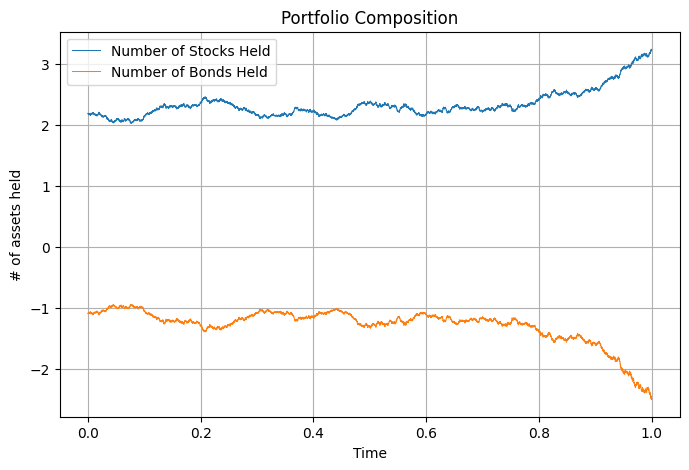

In [ ]:
#Imports
from numpy import random
from scipy.stats import lognorm
np.random.seed(111)

#Constants
S0 = 1
K = 2
sigma = 0.2
r = 0.05
mu = 0.2
T = 1

def get_stock_prices(paths, steps, S0, K, sigma, r, mu, T):
    delta_t = T / steps
    stock_prices = np.zeros((paths, steps+1))
    for j in range(paths):
        stock_prices[j, 0] = S0
        for i in range(steps):
            delta_w = np.random.normal(0, math.sqrt(delta_t))
            stock_prices[j, i + 1] = stock_prices[j, i] * math.exp((mu - 0.5 * (sigma ** 2)) * delta_t + sigma * delta_w)
    return stock_prices

def simulate_option_prices(stock_prices, S0, K, sigma, r, mu, T):
  delta_t = T / len(stock_prices[0] - 1)
  option_prices = np.zeros((len(stock_prices), len(stock_prices[0])))
  stock_positions = np.zeros((len(stock_prices), len(stock_prices[0])))
  bond_positions = np.zeros((len(stock_prices), len(stock_prices[0])))
  replicating_portfolio_value = np.zeros((len(stock_prices), len(stock_prices[0])))

  option_prices[:, 0] = stock_prices[0, 0]**K * math.exp(r * (K - 1) * (T - 0 * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - 0 * delta_t))
  stock_positions[:, 0] = K * stock_prices[0, 0] ** (K - 1) * math.exp(r * (K - 1) * (T - 0 * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - 0 * delta_t))
  bond_positions[:, 0] = math.exp(- r * 0 * delta_t) * stock_prices[0, 0] ** K * (1 - K) * math.exp(r * (K - 1) * (T - 0 * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - 0 * delta_t))
  replicating_portfolio_value[:, 0] = stock_positions[:, 0] * stock_prices[:, 0] + bond_positions[:, 0] * math.exp(r * (0 * delta_t))

  for j in range(0, len(stock_prices)):
    for i in range(1, len(stock_prices[0])):
      option_prices[j, i] = stock_prices[j, i]**K * math.exp(r * (K - 1) * (T - i * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - i * delta_t))
      current_replicating_value = stock_positions[j, i-1] * stock_prices[j, i] + bond_positions[j, i-1] * math.exp(r * (i * delta_t))

      stock_positions[j, i] = K * stock_prices[j, i] ** (K - 1) * math.exp(r * (K - 1) * (T - i * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - i * delta_t))
      bond_positions[j, i] = (current_replicating_value - stock_positions[j, i] * stock_prices[j, i]) / math.exp(r * (i * delta_t))

      replicating_portfolio_value[j, i] = stock_positions[j, i] * stock_prices[j, i] + bond_positions[j, i] * math.exp(r * (i * delta_t))
  return option_prices, replicating_portfolio_value, stock_positions, bond_positions


def plot_option_prices(option_prices, replicating_portfolio_value, stock_prices):
  time_grid = np.linspace(0, T, option_prices.shape[1])[1:]  # remove first time point
  plt.figure(figsize=(8,5))
  plt.plot(time_grid, option_prices[0,1:], label='Analytical Option Price', lw=0.75)
  plt.plot(time_grid, replicating_portfolio_value[0,1:], label='Replicating Portfolio Value', lw=0.75, linestyle=':')
  plt.plot(time_grid, stock_prices[0,1:], label='Underlying Stock Price', lw=0.75, linestyle='--')
  plt.xlabel('Time')
  plt.ylabel('Value')
  plt.title(f'Option vs Replicating Portfolio (K={K})')
  plt.legend()
  plt.grid(True)
  plt.show()

def plot_portfolio_positions(stock_positions, bond_positions):
  time_grid = np.linspace(0, T, stock_positions.shape[1])[1:]  # remove first time point
  plt.figure(figsize=(8,5))
  plt.plot(time_grid, stock_positions[0,1:], label='Number of Stocks Held', lw=0.75)
  plt.plot(time_grid, bond_positions[0,1:], label='Number of Bonds Held', lw=0.75)
  plt.xlabel('Time')
  plt.ylabel('# of assets held')
  plt.title('Portfolio Composition')
  plt.legend()
  plt.grid(True)
  plt.show()


stock_prices = get_stock_prices(1, 10000, S0, K, sigma, r, mu, T)
option_prices, replicating_portfolio_value, stock_positions, bond_positions = simulate_option_prices(stock_prices, S0, K, sigma, r, mu, T)
plot_option_prices(option_prices, replicating_portfolio_value, stock_prices)
plot_portfolio_positions(stock_positions, bond_positions)


### Approximation Error: Time Steps
Above we saw that the replicating portfolio follows the option's value very closely when the number of time steps is large (and each time step is small), but the method functions less well when the time steps are large. To investigate the impact of the size of the time step, we can investigate the mean squared tracking error. In this case, as we are evaluating how well the replicating portfolio tracks the derivative's price, we are not only interested in the error in the final time step, but rather compute the error in each time step and take the average of this. Theoretically, we expect this MSTE to be of the order $Δt$, corresponding to a slope of $-1$ in the log-log plot below.

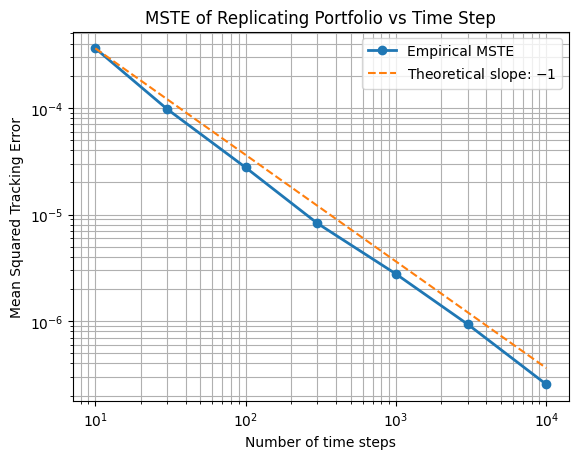

In [ ]:
def calculate_MSTE_varying_time_step():
  paths = 1000
  average_mste = np.zeros(7)
  step_counts = [10, 30, 100, 300, 1000, 3000, 10000]
  for i, steps in enumerate(step_counts):
      stock_prices = get_stock_prices(paths, steps, S0, K, sigma, r, mu, T)
      option_prices, replicating_portfolio_value, stock_positions, bond_positions = simulate_option_prices(stock_prices, S0, K, sigma, r, mu, T)
      mste_sum = 0
      for j in range(paths):
          errors = replicating_portfolio_value[j,1:] - option_prices[j,1:]
          squared_errors = errors**2
          mean_squared_error = np.mean(squared_errors)
          mste_sum += mean_squared_error
      average_mste[i] = mste_sum / paths
  return average_mste, step_counts

def plot_MSTE_varying_time_step():
  average_mste, step_counts = calculate_MSTE_varying_time_step()
  theoretical_line = (average_mste[0] * step_counts[0] / step_counts)
  plt.loglog(step_counts, average_mste, marker='o', lw=2, label="Empirical MSTE")
  plt.loglog(step_counts, theoretical_line, '--', label=r"Theoretical slope: $-1$")
  plt.xlabel('Number of time steps')
  plt.ylabel('Mean Squared Tracking Error')
  plt.title('MSTE of Replicating Portfolio vs Time Step')
  plt.grid(True, which='both')
  plt.legend()
  plt.show()

plot_MSTE_varying_time_step()

As we saw for the case of the Monte Carlo pricing error, the observed tracking errors follow the theoretically expected relationship quite well, though the error in the first time step (with the largest step size) is somewhat higher than expected.

### The Effect of Transaction Costs
In the model above, it was assumed that the replicating portfolio can be updated without any transaction costs. Now, if we assume there is a transaction cost of $c$ as a fraction of the stock price each time it is traded, there is a tradeoff: if the portfolio is updated often, large transaction costs are incurred, but if the portfolio is updated seldom, it will not follow the value of the derivative as well.

To balance between these two forces, one method involves updating the portfolio only if the current number of stocks held differs too much from the desired number. We thus rebalance the portfolio if the current stock position is outside of the tolerance interval, so if $$w^S_{t-Δt} ∉ [\frac{\partial F_t}{\partial S_t}+ϵ, \frac{\partial F_t}{\partial S_t}-ϵ]$$ in which case $w^S_t = \frac{\partial F_t}{\partial S_t}$ and the rebalancing cost becomes $C_t = c· S_t·(w^S_t-w^S_{t-Δt})$. If, on the other hand, $$w^S_{t-Δt} ∈ [\frac{\partial F_t}{\partial S_t}+ϵ, \frac{\partial F_t}{\partial S_t}-ϵ]$$ then $w^S_t = w^S_{t-Δt}$ and $C_t=0$.

If we rebalance the portfolio, the value is updated as $$V_t = w^S_t S_t + w^B_t B_t - \sum_{i=0}^{T/Δt} C_i$$ and the number of bonds held, as in the case of no transaction costs held, is updated to $$w_t^B = \big(V_t - w_t^SS_t \big)/B_t$$

Below, the mean squared tracking error (MSTE) as well as the average terminal value is studied, as a function of the size of the tolerance interval, which is determined by the parameter $ϵ$. We expect the MSTE to be higher for both large and small values of $ϵ$. At small values of $ϵ$, the rebalancing is frequent, leading to large transaction costs, and preventing the replicating portfolio to follow the value of the derivative closely. Conversely, at large values of $ϵ$, the rebalancing is infrequent, also preventing the replicating portfolio to follow the value of the derivative closely. The effect on the average terminal value is similar: for low values of $ϵ$, much money is lost in transaction costs, while for large values of $ϵ$, the impaired ability to follow the value of the derivative can lead to a lower terminal value.

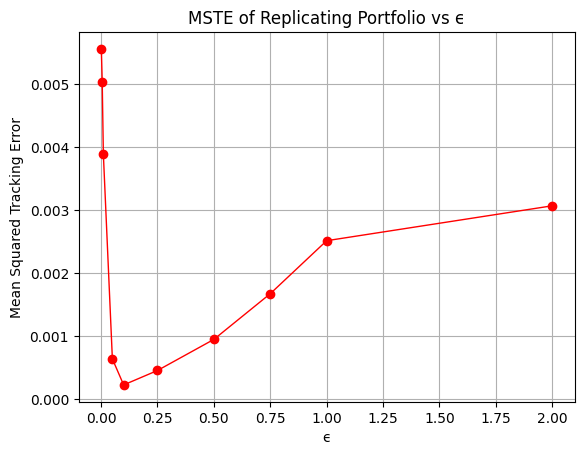

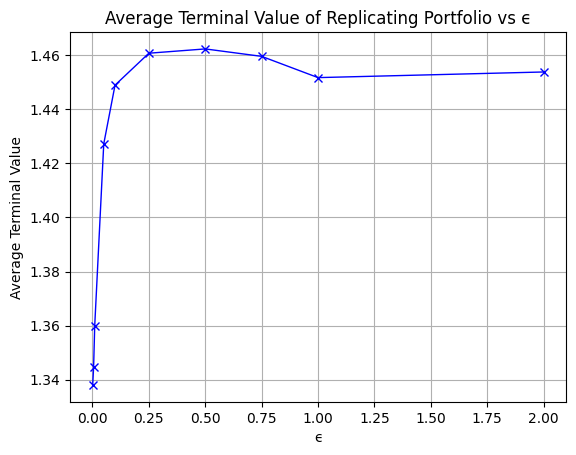

In [ ]:
#Constant
c = 0.01

def replicating_with_transaction_costs(stock_prices, S0, K, sigma, r, mu, T, epsilon):
  delta_t = T / len(stock_prices[0])
  option_prices = np.zeros((len(stock_prices), len(stock_prices[0])))
  stock_positions = np.zeros((len(stock_prices), len(stock_prices[0])))
  bond_positions = np.zeros((len(stock_prices), len(stock_prices[0])))
  replicating_portfolio_value = np.zeros((len(stock_prices), len(stock_prices[0])))

  option_prices[:, 0] = stock_prices[0, 0]**K * math.exp(r * (K - 1) * (T - 0 * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - 0 * delta_t))
  stock_positions[:, 0] = K * stock_prices[0, 0] ** (K - 1) * math.exp(r * (K - 1) * (T - 0 * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - 0 * delta_t))
  bond_positions[:, 0] = math.exp(- r * 0 * delta_t) * stock_prices[0, 0] ** K * (1 - K) * math.exp(r * (K - 1) * (T - 0 * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - 0 * delta_t))
  replicating_portfolio_value[:, 0] = stock_positions[:, 0] * stock_prices[:, 0] + bond_positions[:, 0] * math.exp(r * (0 * delta_t))

  for j in range(0, len(stock_prices)):
    for i in range(1, len(stock_prices[0])):
      option_prices[j, i] = stock_prices[j, i]**K * math.exp(r * (K - 1) * (T - i * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - i * delta_t))
      ideal_stock_position = K * stock_prices[j, i] ** (K - 1) * math.exp(r * (K - 1) * (T - i * delta_t) + (sigma ** 2) / 2 * (K ** 2 - K) * (T - i * delta_t))

      if (ideal_stock_position - epsilon) < stock_positions[j, i-1] < (ideal_stock_position + epsilon):
        stock_positions[j, i] = stock_positions[j, i-1]
        transaction_cost = 0
      else:
        stock_positions[j, i] = ideal_stock_position
        transaction_cost = c * abs(ideal_stock_position - stock_positions[j, i-1]) * stock_prices[j, i]

      current_replicating_value = stock_positions[j, i-1] * stock_prices[j, i] + bond_positions[j, i-1] * math.exp(r * (i * delta_t)) - transaction_cost
      bond_positions[j, i] = (current_replicating_value - stock_positions[j, i] * stock_prices[j, i]) / math.exp(r * (i * delta_t))
      replicating_portfolio_value[j, i] = stock_positions[j, i] * stock_prices[j, i] + bond_positions[j, i] * math.exp(r * (i * delta_t))

  return option_prices, replicating_portfolio_value, stock_positions, bond_positions

def calculate_MSTE(paths, replicating_portfolio_value, option_prices):
    mse_sum = 0
    for j in range(paths):
          errors = replicating_portfolio_value[j,1:] - option_prices[j,1:]
          squared_errors = errors**2
          mean_squared_error = np.mean(squared_errors)
          mse_sum += mean_squared_error
    return mse_sum / paths

def get_terminal_value_and_MSTE(epsilon_values):
  paths = 100
  MSTE = np.zeros(len(epsilon_values))
  average_terminal_value = np.zeros(len(epsilon_values))
  stock_prices = get_stock_prices(paths, 1000, S0, K, sigma, r, mu, T)
  for epsilon in enumerate(epsilon_values):
    option_prices, replicating_portfolio_value, stock_positions, bond_positions = replicating_with_transaction_costs(stock_prices, S0, K, sigma, r, mu, T, epsilon[1])
    MSTE[epsilon[0]] = calculate_MSTE(paths, replicating_portfolio_value, option_prices)
    average_terminal_value[epsilon[0]] = np.mean(replicating_portfolio_value[:, -1]) / S0
  return MSTE, average_terminal_value, stock_prices

def plot_terminal_value_and_MSTE(MSTE, average_terminal_value, epsilon_values):
  plt.plot(epsilon_values, MSTE, marker='o', lw=1, color='red')
  plt.xlabel('ϵ')
  plt.ylabel('Mean Squared Tracking Error')
  plt.title('MSTE of Replicating Portfolio vs ϵ')
  plt.grid(True, which='both')
  plt.show()

  plt.plot(epsilon_values, average_terminal_value, marker='x', lw=1, color='blue')
  plt.xlabel('ϵ')
  plt.ylabel('Average Terminal Value')
  plt.title('Average Terminal Value of Replicating Portfolio vs ϵ')
  plt.grid(True, which='both')
  plt.show()

epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1, 2]
MSTE, average_terminal_value, stock_prices = get_terminal_value_and_MSTE(epsilon_values)
plot_terminal_value_and_MSTE(MSTE, average_terminal_value, epsilon_values)

The value of $ϵ$ that is optimal, in terms of MSTE and average terminal value, depends on the parameters, but with the given parameters the optimal value of $ϵ$ seems to be around 0.25. With this value, we can simulate the the value of the replicating value and compare it to the value of the option (which, in contrast to the replicating portfolio, is not impacted by transaction costs). The result of this is shown in the graph below.

Note that in some simulations, the value of the replicating portfolio is higher than the analytical value of the option. This is counterintuitive, because the replicating portfolio loses value over time due to transaction costs. The explanation, however, lies in the fact that the replicating portfolio does not rebalance unless its stock- and bond weights deviate too much from the theoretically optimal position. Because of this, the replicating portfolio can have 'too many' stocks, and if the stocks perform better than expected, the value of the replicating portfolio can exceed the value of the option, despite the transaction costs! Similarly, is may also happen if the replicating portfolio has too few stocks, and the stocks perform worse than expected.

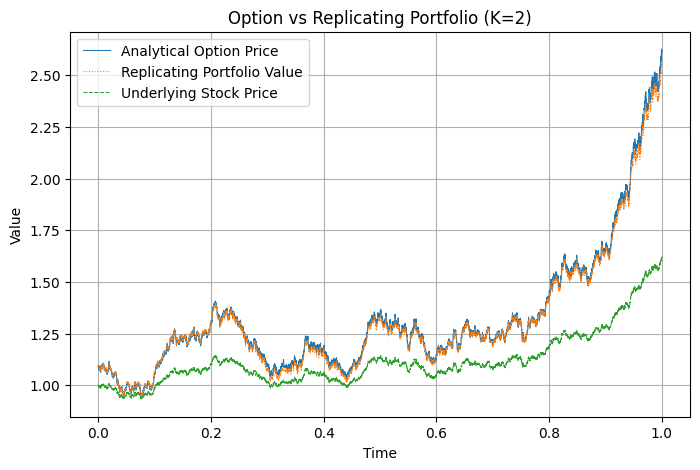

In [ ]:
np.random.seed(111)
stock_prices_2 = get_stock_prices(1, 10000, S0, K, sigma, r, mu, T)
option_prices, replicating_portfolio_value, stock_positions, bond_positions = replicating_with_transaction_costs(stock_prices_2, S0, K, sigma, r, mu, T, 0.25)
plot_option_prices(option_prices, replicating_portfolio_value, stock_prices_2)

## Derivative 2: The Arithmetic Asian Option

### Payoff and Pricing

We now turn to a derivative for which the situation is very different from the power payoff derivative considered in the section above. While the payoff of the derivative above depended only on the value of the underlying asset at its maturity, the payoff of an Asian option depends on the value of the underlying asset at all time points up to maturity. This path dependence makes Asian options more difficult to price analytically, while at the same time making them a natural application of Monte Carlo simulation.

Let us consider an arithmetic-average Asian call option with maturity at time $T$ and strike price $K$. Let the stock price be observed at the equally spaced times

$$
0 < t_1 < t_2 < \cdots < t_n = T
$$

and define the arithmetic average of the stock price over these observation times as

$$
A_T = \frac{1}{n}\sum_{i=1}^{n}S_{t_i}
$$

The payoff of the option at maturity is then given by

$$
X = \max(A_T-K,0)
$$

Unlike a  European call option, whose payoff depends only on the terminal value $S_T$, the payoff of the Asian option depends on the entire sequence

$$
S_{t_1}, S_{t_2}, \ldots, S_{t_n}
$$

As a result, two stock price paths that end at the same terminal value $S_T$ can result in different option payoffs - something which would not be the case for a European call option. Under the risk-neutral measure $\mathbb{Q}$, the dynamics of the stock price are assumed to follow the stochastic differential equation

$$
dS_t = rS_tdt+\sigma S_tdW_t^\mathbb{Q}
$$

where, as above, $r$ is the risk-free interest rate, $\sigma$ is the volatility of the underlying stock, and $W_t^\mathbb{Q}$ is a Brownian motion under the probability measure $\mathbb{Q}$. The fair price of the Asian option at time $t$ is therefore

$$
\begin{align}
F_t
&= e^{-r(T-t)}𝔼^\mathbb{Q}(X) \\[6pt]
&= e^{-r(T-t)}𝔼^\mathbb{Q}(\max(A_T-K,0)) \\[6pt]
&= e^{-r(T-t)}𝔼^\mathbb{Q}\Big(\max\Big(\frac{1}{n}\sum_{i=1}^{n}S_{t_i} - K,0\Big)\Big) \\[6pt]
\end{align}
$$

For a European call option, the terminal stock price $S_T$ is lognormally distributed, which allows the expected value of the payoff to be calculated analytically. For the arithmetic-average Asian option, however, the payoff depends on the sum of several correlated lognormal random variables, and the expected value does not have a closed-form expression. Consequently, there is no closed-form pricing formula for the arithmetic-average Asian option.

Monte Carlo simulation, however, provides a natural method for approximating this price. By simulating a large number of stock price paths under the risk-neutral measure, calculating the arithmetic average and resulting payoff for each path, and then discounting this payoff, we obtain an estimate of the fair price.

To illustrate the path-dependent nature of the Asian call option, the figure below shows the price paths of samples of the stock, under the risk-neutral measure, along with the running averages, used in computing the option's payoff.

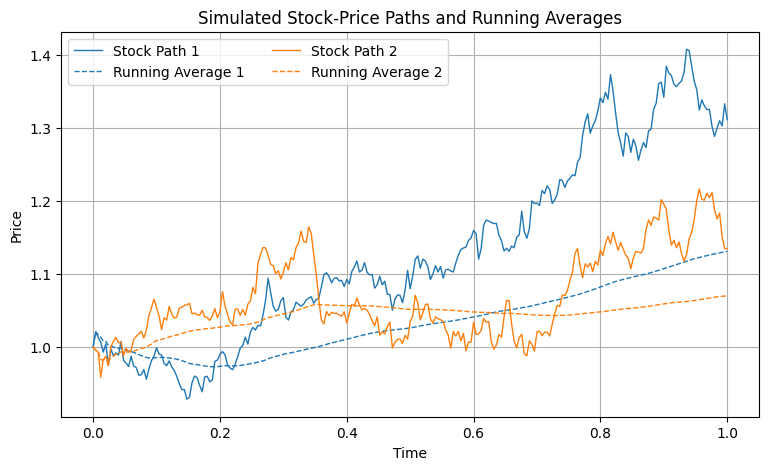

In [ ]:
#Constants
S0 = 1
K = 1
sigma = 0.2
r = 0.05
mu = 0.2
T = 1
np.random.seed(1)

def monte_carlo_derivative_price_2(S0, K, sigma, r, T, N, n):
    dt = T / n
    Z = np.random.normal(size=(N, n))
    paths = np.zeros((N, n + 1))
    paths[:, 0] = S0
    for i in range(n):
        paths[:, i + 1] = (paths[:, i] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, i]))
    arithmetic_average = np.mean(paths[:, 1:], axis=1)
    payoffs = np.maximum(arithmetic_average - K, 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    return paths, price

def plot_asian_option_paths(S0, K, sigma, r, T, paths, steps):
    stock_prices, _ = monte_carlo_derivative_price_2(S0, K, sigma, r, T, paths, steps)
    time_grid = np.linspace(0, T, steps + 1)

    running_average = np.zeros((paths, steps + 1))
    running_average[:, 0] = S0
    for i in range(1, steps + 1):
        running_average[:, i] = np.mean(stock_prices[:, 1:i + 1], axis=1)

    plt.figure(figsize=(9, 5))
    for j in range(paths):
        stock_line, = plt.plot(time_grid, stock_prices[j], lw=1, linestyle='-', label=f"Stock Path {j+1}")
        plt.plot(time_grid, running_average[j], lw=1, linestyle='--', color=stock_line.get_color(), label=f"Running Average {j+1}")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.title("Simulated Stock-Price Paths and Running Averages")
    plt.legend(ncol=2)
    plt.grid(True)
    plt.show()

plot_asian_option_paths(S0, K, sigma, r, T, 2, 250)

### Different Parameters' Impact on Derivative Price
For the "power option" considered above, the impact of the different parameters (such as the volatility and time to maturity) are easy to understand, as the formula for the analytical price of the option involves these parameters. In the case of the Asian option, however, the impact of the parameters is not as straightforward, as there is no analytical formula for the price. The impact of some of the parameters is somewhat intuitive: decreasing the strike price, for instance, increases the price of the option, but the effect of an increased maturity, for instance, is not as obvious. Hence, to illustrate the impact of these parameters, we show how the price of the Asian option depends on the strike price $K$, volatility $σ$, risk-free interest rate $r$, and the time to maturity $T$. While each of these parameters is varied, the other parameters are held constant, allowing the impact of varying each parameter to be studied.


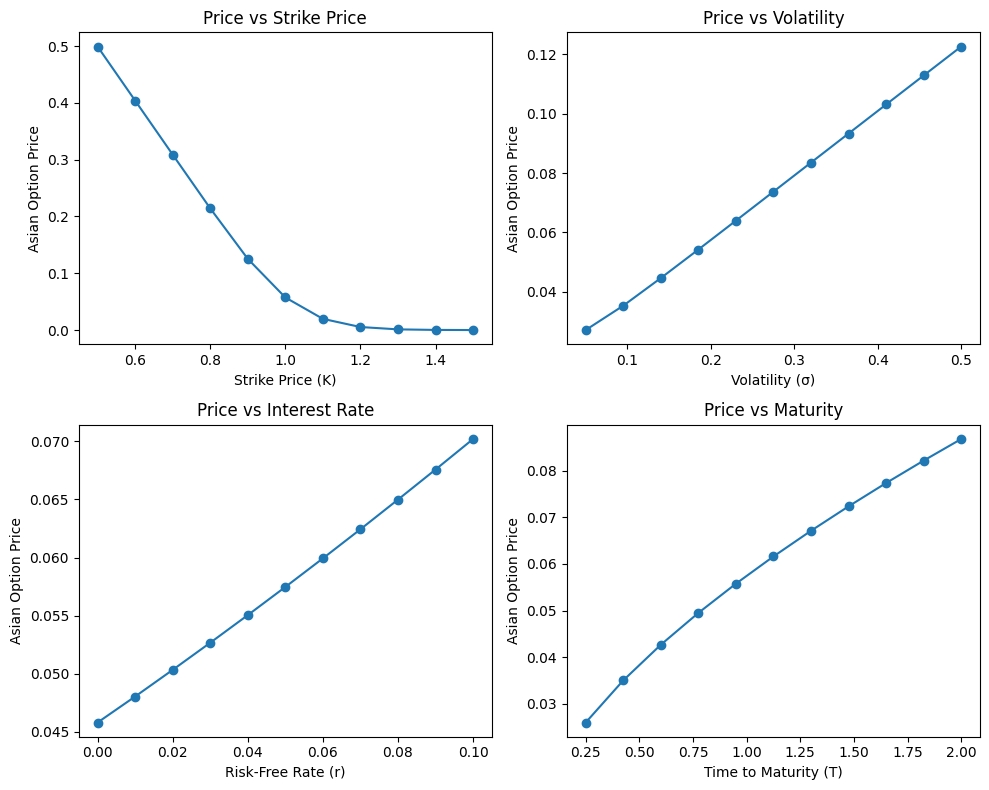

In [ ]:
def arithmetic_asian_option_price(S0, K, sigma, r, T, n, N, Z):
        dt = T / n
        paths = np.zeros((N, n + 1))
        paths[:, 0] = S0

        for i in range(n):
            paths[:, i + 1] = (paths[:, i]* np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, i]))
        arithmetic_average = np.mean(paths[:, 1:], axis=1)
        payoffs = np.maximum(arithmetic_average - K, 0)

        return np.exp(-r * T) * np.mean(payoffs)

def plot_asian_option_parameter_sensitivity(S0, K, sigma, r, T, N, n):
    # Simulate the random variables once so that the same random variables are used for every parameter value
    Z = np.random.normal(size=(N, n))

    K_values = np.linspace(0.5, 1.5, 11)
    sigma_values = np.linspace(0.05, 0.5, 11)
    r_values = np.linspace(0.0, 0.10, 11)
    T_values = np.linspace(0.25, 2, 11)

    prices_K = []
    prices_sigma = []
    prices_r = []
    prices_T = []

    # Vary strike price
    for K_value in K_values:
        prices_K.append(arithmetic_asian_option_price(S0, K_value, sigma, r, T, n, N, Z))

    # Vary volatility
    for sigma_value in sigma_values:
        prices_sigma.append(arithmetic_asian_option_price(S0, K, sigma_value, r, T, n, N, Z))

    # Vary interest rate
    for r_value in r_values:
        prices_r.append(arithmetic_asian_option_price(S0, K, sigma, r_value, T, n, N, Z))

    # Vary maturity
    for T_value in T_values:
        prices_T.append(arithmetic_asian_option_price(S0, K, sigma, r, T_value, n, N, Z))

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].plot(K_values, prices_K, marker='o')
    axes[0, 0].set_xlabel("Strike Price (K)")
    axes[0, 0].set_ylabel("Asian Option Price")
    axes[0, 0].set_title("Price vs Strike Price")

    axes[0, 1].plot(sigma_values, prices_sigma, marker='o')
    axes[0, 1].set_xlabel("Volatility (σ)")
    axes[0, 1].set_ylabel("Asian Option Price")
    axes[0, 1].set_title("Price vs Volatility")

    axes[1, 0].plot(r_values, prices_r, marker='o')
    axes[1, 0].set_xlabel("Risk-Free Rate (r)")
    axes[1, 0].set_ylabel("Asian Option Price")
    axes[1, 0].set_title("Price vs Interest Rate")

    axes[1, 1].plot(T_values, prices_T, marker='o')
    axes[1, 1].set_xlabel("Time to Maturity (T)")
    axes[1, 1].set_ylabel("Asian Option Price")
    axes[1, 1].set_title("Price vs Maturity")

    plt.tight_layout()
    plt.show()

plot_asian_option_parameter_sensitivity(S0, K, sigma, r, T, 10000, 250)

As seen in the figures above, the price of the Asian option decreases as the strike price increases. This is quite intuitive: a higher strike makes it less likely that the average stock price exceeds the strike. The price of the option also increases, seemingly linearly, with the volatility of the underlying asset. This is also reasonable: it increases the potential upside of the average stock price while the option holder's downside is limited to a zero payoff. The impact of a higher risk-free rate is similar to that of a higher volatility: a higher interest rate increases the drift of the underlying asset under the risk-neutral measure, although the effect is in part offset by the fact that a higher interest rate also makes the payoff discounted more heavily. Increasing the time to maturity also increases the value of the option: since the drift of the underlying asset under the risk-neutral measure is positive, the average price of the underlying asset tends to increase over time, increasing the expected payoff and thus the value of the Asian option, although a longer time to maturity also contributes to a heavier discounting.


### The Geometric Asian Option: A Lower Bound of the Arithmetic Asian Option Price
As mentioned above, the price of an arithmetic Asian option has no analytical formula, but it is possible to derive an analytical formula for the price of an Asian option with geometric averaging. Furthermore, it can be shown that the price of the geometric Asian option provides a lower bound on the price of the arithmetic Asian option, which we will begin with.

In general, the AM-GM Inequality states that the arithmetic mean (AM) is greater than or equal to the geometric mean (GM) of a series of non-negative numbers, with strict inequality unless all numbers in the series are all equal to one another. This inequality can be derived from Jensen's inequality. Since the natural logarithm is a concave function, Jensen's inequality gives

$$
\ln\left(\frac{1}{n}\sum_{i=1}^n x_i\right)
\geq
\frac{1}{n}\sum_{i=1}^n \ln(x_i)
$$

The right-hand side can be rewritten as

$$
\frac{1}{n}\sum_{i=1}^n \ln(x_i) = \frac{1}{n}\ln\left(\prod_{i=1}^n x_i\right) = \ln\left(\prod_{i=1}^n x_i\right)^{1/n}
$$

From this, it follows that

$$
\ln\left(\frac{1}{n}\sum_{i=1}^n x_i\right)
\geq
\ln\left(\prod_{i=1}^n x_i\right)^{1/n}
$$

Since the natural logarithm is an increasing function, this results in the AM-GM Inequality:

$$
\boxed{
\frac{1}{n}\sum_{i=1}^n x_i
\geq
\left(\prod_{i=1}^n x_i\right)^{1/n}
}
$$


Applying this to the stock prices at the monitoring dates gives

$$
\frac{1}{n}\sum_{i=1}^n S_{t_i}
\geq
\left(\prod_{i=1}^n S_{t_i}\right)^{1/n}
$$

so the arithmetic average of the stock price is always greater than or equal to its geometric average. Consequently,

$$
\max\left(\frac{1}{n}\sum_{i=1}^n S_{t_i}-K,0\right)
\geq
\max\left(\left(\prod_{i=1}^n S_{t_i}\right)^{1/n}-K,0\right)
$$

Taking expectations and discounting therefore shows that the price of an Asian call option with geometric averaging provides a lower bound for the price of an Asian call option with arithmetic averaging. Now, let us turn to the task of pricing the Asian option with geometric averaging. Consider a geometric Asian call option with strike price $K$ and maturity $T$. The geometric average of the underlying stock price is defined as

$$G_T = \exp\left(\frac{1}{T}\int_0^T \log(S_t)\,dt\right)$$

and the payoff of the option at maturity is

$$X=\max(G_T-K,0)$$

Under the risk-neutral measure $\mathbb{Q}$, the stock price follows the SDE

$$dS_t=rS_tdt+\sigma S_tdW_t^\mathbb{Q}$$

with solution
$$S_t=S_0\exp\left(\left(r-\frac{1}{2}\sigma^2\right)t+\sigma W_t^\mathbb{Q}\right)$$

Taking logarithms gives

$$\log(S_t)=\log(S_0)+\left(r-\frac{1}{2}\sigma^2\right)t+\sigma W_t^\mathbb{Q}$$

Substituting this into the definition of $G_T$ gives

$$
\begin{aligned}
G_T
&= \exp\left[\frac{1}{T}\int_0^T\left(\log(S_0)+\left(r-\frac{1}{2}\sigma^2\right)t+\sigma W_t^\mathbb{Q}\right)dt\right] \\[6pt]
&= \exp\left[\frac{1}{T}\left(T\log(S_0)+\left(r-\frac{1}{2}\sigma^2\right)\int_0^T t\,dt+\sigma\int_0^T W_t^\mathbb{Q}dt\right)\right] \\[6pt]
&= \exp\left[\log(S_0)+\frac{T}{2}\left(r-\frac{1}{2}\sigma^2\right)+\frac{\sigma}{T}\int_0^T W_t^\mathbb{Q}dt\right] \\[6pt]
&= S_0 \exp\Big(\frac{T}{2}\big(r-\frac{σ^2}{2})\Big) * \exp\Big(\frac{σ}{T} \int^T_0 W^{\mathbb{Q}}_t dt\Big)
\end{aligned}
$$

The remaining stochastic integral can be rewritten using Itô's product rule. Consider the process $(T-t)W_t^\mathbb{Q}$. Its differential is

$$d\left[(T-t)W_t^\mathbb{Q}\right]=-W_t^\mathbb{Q}dt+(T-t)dW_t^\mathbb{Q}$$

Rearranging gives

$$W_t^\mathbb{Q}dt=(T-t)dW_t^\mathbb{Q}-d\left[(T-t)W_t^\mathbb{Q}\right]$$

Integrating from $0$ to $T$ gives

$$\int_0^T W_t^\mathbb{Q}dt=\int_0^T(T-t)dW_t^\mathbb{Q}-\left[(T-t)W_t^\mathbb{Q}\right]_0^T$$

Since $W_0^\mathbb{Q}=0$ and $T-T=0$, we get that

$$\int_0^T W_t^\mathbb{Q}dt=\int_0^T(T-t)dW_t^\mathbb{Q}$$

By Itô isometry, the stochastic integral on the right-hand side is normally distributed with zero mean and variance of

$$
\begin{aligned}
\operatorname{V}\left(\int_0^T(T-t)dW_t^\mathbb{Q}\right)
&= \int_0^T(T-t)^2dt \\[6pt]
&= \left[-\frac{(T-t)^3}{3}\right]_0^T \\[6pt]
&= \frac{T^3}{3}
\end{aligned}
$$

Therefore,

$$
\int_0^T W_t^\mathbb{Q}dt
\sim
N\left(0,\frac{T^3}{3}\right)
$$

and hence

$$
\frac{\sigma}{T} \int_0^T W_t^\mathbb{Q}dt \sim N\left(0,\frac{\sigma^2T}{3}\right)
$$

Define

$$\sigma_G=\frac{\sigma}{\sqrt{3}}$$

so that

$$\frac{\sigma}{T}\int_0^T W_t^\mathbb{Q}dt=\sigma_G\sqrt{T}Z, \qquad
Z\sim\mathcal{N}(0,1)$$

Furthermore, define

$$b=\frac{1}{2}\left(r-\frac{\sigma^2}{2}\right)$$

The geometric average can therefore be written as

$$G_T=S_0\exp\left(bT+\sigma_G\sqrt{T}Z\right)$$

As we can see, this has the same form as the expression for the stock price at maturity:
$$S_T=S_0\exp\left(\big(r-\frac{σ^2}{2}\big)T+\sigma\sqrt{T}Z\right)$$

Hence, we can use the usual Black-Scholes formula for the price of a call option, with slight modification. Thus, the analytical price of the geometric Asian call is

$$
\boxed{C_G=S_0e^{\left(b+\frac{1}{2}\sigma_G^2-r\right)T}\Phi(d_1)-Ke^{-rT}\Phi(d_2)}$$

where

$$\boxed{b=\frac{1}{2}\left(r-\frac{1}{2}\sigma^2\right), \qquad \sigma_G=\frac{\sigma}{\sqrt{3}}}$$

and

$$\boxed{d_1=\frac{\log(S_0/K)+\left(b+\sigma_G^2\right)T}{\sigma_G\sqrt{T}},\qquad d_2=d_1-\sigma_G\sqrt{T}}$$

Below, the price of the Asian call option with geometric averaging is implemented, and the price is compared with that of the Asian call option with arithmetic averaging. As above, this comparison is done with various values for the strike price, volatility, risk-free interest rate, and time to maturity. This allows visualizing the fact that the geometric Asian option does indeed provide a lower bound for the price of the arithmetic Asian option, though there is a slight discrepancy between the two options, as the price of the geometric option assumes  continuos monitoring. Below, the price of the arithmetic Asian option is, as above, simulated using Monte Carlo, while the price of the geometric Asian option is calculated exactly. This introduces an element of randomness, though as the Monte Carlo simulation of the price uses a large number of simulations, this effect will likely be quite small

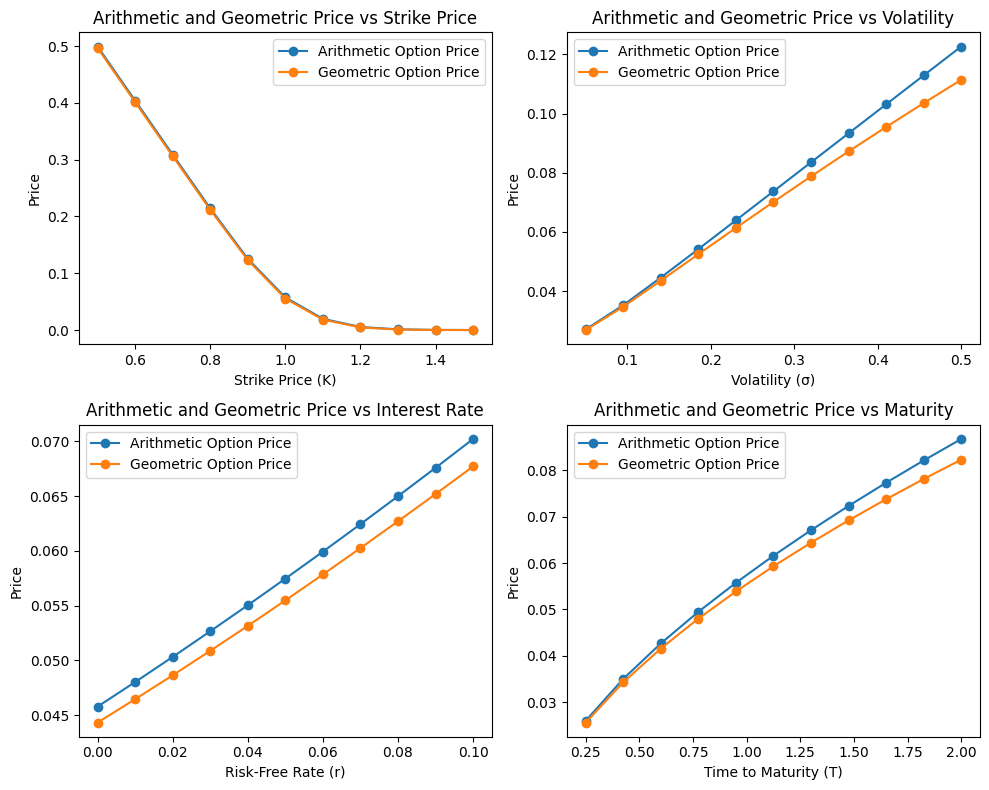

In [ ]:
from scipy.stats import norm
import math
import numpy as np
import matplotlib.pyplot as plt

#Constants
S0 = 1
K = 1
sigma = 0.2
r = 0.05
mu = 0.2
T = 1
np.random.seed(1)

def geometric_asian_option_price(S0, K, sigma, r, T):
    sigma_G = sigma / math.sqrt(3)
    b = 0.5 * (r - 0.5 * sigma**2)
    d1 = (math.log(S0 / K) + (b + sigma_G**2) * T) / (sigma_G * math.sqrt(T))
    d2 = d1 - sigma_G * math.sqrt(T)
    price = (S0 * math.exp((b + 0.5 * sigma_G**2 - r) * T) * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2))
    return price

def plot_asian_prices(S0, K, sigma, r, T, N, n):
    # Generate the random variables once
    Z = np.random.normal(size=(N, n))

    # Parameter values
    K_values = np.linspace(0.5, 1.5, 11)
    sigma_values = np.linspace(0.05, 0.5, 11)
    r_values = np.linspace(0.0, 0.10, 11)
    T_values = np.linspace(0.25, 2.0, 11)

    diff_K = []
    arithmetic_K = []
    arithmetic_sigma = []
    arithmetic_r = []
    arithmetic_T = []
    geometric_K = []
    geometric_sigma = []
    geometric_r = []
    geometric_T = []

    # Vary strike price
    for K_value in K_values:
        arithmetic_price = arithmetic_asian_option_price(S0, K_value, sigma, r, T, n, N, Z)
        geometric_price = geometric_asian_option_price(S0, K_value, sigma, r, T)
        arithmetic_K.append(arithmetic_price)
        geometric_K.append(geometric_price)

    # Vary volatility
    for sigma_value in sigma_values:
        arithmetic_price = arithmetic_asian_option_price(S0, K, sigma_value, r, T, n, N, Z)
        geometric_price = geometric_asian_option_price(S0, K, sigma_value, r, T)
        arithmetic_sigma.append(arithmetic_price)
        geometric_sigma.append(geometric_price)

    # Vary interest rate
    for r_value in r_values:
        arithmetic_price = arithmetic_asian_option_price(S0, K, sigma, r_value, T, n, N, Z)
        geometric_price = geometric_asian_option_price(S0, K, sigma, r_value, T)
        arithmetic_r.append(arithmetic_price)
        geometric_r.append(geometric_price)

    # Vary maturity
    for T_value in T_values:
        arithmetic_price = arithmetic_asian_option_price(S0, K, sigma, r, T_value, n, N, Z)
        geometric_price = geometric_asian_option_price(S0, K, sigma, r, T_value)
        arithmetic_T.append(arithmetic_price)
        geometric_T.append(geometric_price)

    # Plot the results
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].plot(K_values, arithmetic_K, marker='o', label="Arithmetic Option Price")
    axes[0, 0].plot(K_values, geometric_K, marker='o', label="Geometric Option Price")
    axes[0, 0].set_xlabel("Strike Price (K)")
    axes[0, 0].set_ylabel("Price")
    axes[0, 0].legend()
    axes[0, 0].set_title("Arithmetic and Geometric Price vs Strike Price")

    axes[0, 1].plot(sigma_values, arithmetic_sigma, marker='o', label="Arithmetic Option Price")
    axes[0, 1].plot(sigma_values, geometric_sigma, marker='o', label="Geometric Option Price")
    axes[0, 1].set_xlabel("Volatility (σ)")
    axes[0, 1].set_ylabel("Price")
    axes[0, 1].legend()
    axes[0, 1].set_title("Arithmetic and Geometric Price vs Volatility")

    axes[1, 0].plot(r_values, arithmetic_r, marker='o', label="Arithmetic Option Price")
    axes[1, 0].plot(r_values, geometric_r, marker='o', label="Geometric Option Price")
    axes[1, 0].set_xlabel("Risk-Free Rate (r)")
    axes[1, 0].set_ylabel("Price")
    axes[1, 0].legend()
    axes[1, 0].set_title("Arithmetic and Geometric Price vs Interest Rate")

    axes[1, 1].plot(T_values, arithmetic_T, marker='o', label="Arithmetic Option Price")
    axes[1, 1].plot(T_values, geometric_T, marker='o', label="Geometric Option Price")
    axes[1, 1].set_xlabel("Time to Maturity (T)")
    axes[1, 1].set_ylabel("Price")
    axes[1, 1].legend()
    axes[1, 1].set_title("Arithmetic and Geometric Price vs Maturity")


    plt.tight_layout()
    plt.show()

plot_asian_prices(S0, K, sigma, r, T, 10000, 250)

Above, we can see that the price of the geometric Asian option is lower than that of the arithmetic Asian option, for all values of the strike price ($K$), volatility($σ$), risk-free interest rate ($r$), and time to maturity ($T$). We also see that the gap between the two prices increases as $σ$ and $T$ increase, but seems to be relatively insensitive to changes in $r$. Though not very visible in the plot, the difference in price decreases as $K$ increases, with larger changes when $K$ is close to $S_0$, and the difference in price not being very sensitive to changes in $K$ when $K$ is not close to $S_0$ (for options deep in-the-money or out-of-the-money).

## Derivative 3: The American Put Option
### Price and Stopping Time
American put options are another form of option which, like the arithmetic Asian option, lacks an analytical formula for its price. Unlike European options, American options allow exercise at any time before or at the maturity of the option, unlike European options, which allows exercise only at the maturity. Hence, American options are similar to Asian option in the way that it is not only the value of the underlying asset at maturity which matters, but also at time points prior to the maturity. Unlike Asian options, however, American options also require the option's owner to choose, at any time, whether or not to then exercise the option. This creates a complication: pricing an American option also requires determining the optimal 'stopping time', when the option is exercised. It is well-known that it is never optimal to exercise an American call option (assuming no dividends paid by the underlying asset), since this forfeits the time value of the option. Hence, the fair price of an American call option is equal to the corresponding European call option, but this is not the case for American put options, where early exercise can be optimal.

For the American put option, the payoff is given by
$$\max(K-S_τ,0)$$
where $S_τ$ is the price of the underlying asset at $τ\in[0,T]$, the time when the option is exercised. The fair price of the option at present is given by
$$P_A = \sup_τ(\mathbb{E}^\mathbb{Q}[e^{-rτ} \max(K-S_τ,0)])$$
In order to approximate this price, we begin by using the binomial tree to model to the movements of the underlying asset, and then calculate at which points early exercise is optimal, allowing us to approximate the exercise boundary.

### Price and Exercise Boundary: Binomial Tree
Beside determining the price of the American put option, then, we are interested in determining the 'exercise boundary': the price which, at any time, it is optimal to exercise the option if the underlying asset is below. Below we simulate this exercise boundary, for different values of the volatility $σ$, as well as the risk-free interest rate $r$, by constructing the binomial tree of stock prices, and by backward induction determining, at each time step and its possible stock prices, whether the expected value is higher for exercising the option or not. The highest value of the underlying asset, at each time point, for which early exercise is optimal, is the exercise boundary at that time point.

The binomial tree method is a numerical method for pricing derivatives, and works by approximating the continuous price process of the underlying asset as a discrete-time process. For an American option, the method allows us to estimate the exercise boundary $S^*(t)$: the stock price below which it is optimal to exercise the American put option.

To construct the binomial tree, we divide the time interval $[0,T]$ into $n$ equally sized time steps, with time steps of size

$$\Delta t = \frac{T}{n}$$

Starting with the initial stock price $S_0$, the stock price is assumed to either increase by a factor $u$ or decrease by a factor $d$ in each time step. The two possible prices at the next time step are thus

$$S_u = Su$$

and

$$S_d = Sd$$

The up and down factors are given by

$$u = e^{\sigma\sqrt{\Delta t}}$$

and

$$d = \frac{1}{u} = e^{-\sigma\sqrt{\Delta t}}$$

The factors $u$ and $d$ are constructed so that the binomial model is consistent with the volatility of the underlying asset. As $\Delta t$ goes to zero, the binomial model converges to the geometric Brownian motion model for the stock price (which we have seen in the derivatives above).

After $i$ time steps, the stock price can take one of $i+1$ different values. If the asset has taken $j$ upward steps and $i-j$ downward steps, the stock price is given by

$$S_{i,j}=S_0u^jd^{i-j}$$

As usual, the option is priced under the risk-neutral measure. From a no-arbitrage argument, we get that

$$\mathbb{E}^\mathbb{Q}[S_{t+\Delta t}\mid S_t=S]=Se^{r\Delta t}$$

Since the stock can either move to $Su$ (with probability $p$) or $Sd$ (with probability $1-p$), this means that

$$pSu+(1-p)Sd=Se^{r\Delta t}$$

Hence, the probability $p$ for an upward step is
$$p=\frac{e^{r\Delta t}-d}{u-d}$$

To value the option using the binomial tree, as the terminal payoff is

$$P_T=\max(K-S_T,0)$$

the value at every terminal node in the binomial tree is

$$V_{N,i}=\max(K-S_{N,i},0)$$

After calculating the value at each terminal node, we proceed by backward induction to value the option in each node. At a given node, there are two possible decisions: either exercise the option, or continue to hold the option. The value of an immediate exercise is

$$V_{\text{exercise}}=\max(K-S,0)$$
where $S$ is the price of the underlying asset in that node. If the option is not exercised, its continuation value is the expected value of the option, discounted at the risk-free rate:

$$V_{\text{continue}}=e^{-r\Delta t}\left[pV_u+(1-p)V_d\right]$$

where $V_u$ and $V_d$ are the option values following an upward and downward step, respectively. At each time step, the option holder would exercise the option if and only if the exercise value is higher than the the continuation value, so the value of the option in any node is the higher of the two values:

$$V=\max\left(V_{\text{exercise}},V_{\text{continue}}\right)$$


Repeating this backward induction, then, from maturity to the start node gives the option price as

$$P_0=V_{0,0}$$


The backward induction used to determine the price of the option can also be used to determine the exercise boundary. At each node, we compare the immediate exercise value with the continuation value. Exercise is optimal when

$$K-S \geq e^{-r\Delta t}\left[pV_u+(1-p)V_d\right]$$

provided that $S\lt K$

Thus, at each time step $t_i=i\Delta t$, we identify all nodes where immediate exercise is optimal, and the exercise boundary $S^*(t_i)$ is approximated as the highest stock price at which exercise is optimal:

$$S^*(t_i)=\max\left\{S_{i,j}:V_{\text{exercise}}(S_{i,j})\geq V_{\text{continue}}(S_{i,j}),\quad S_{i,j} \lt K\right\}$$

Since the binomial tree only contains discrete set of stock prices, the exercise boundary obtained by this method is also discrete, and can only serve as an approximation to the continuous exercise boundary. As the number of time steps $N$ increases, however, the tree becomes finer and the estimated boundary can better approximate the continuous exercise boundary.


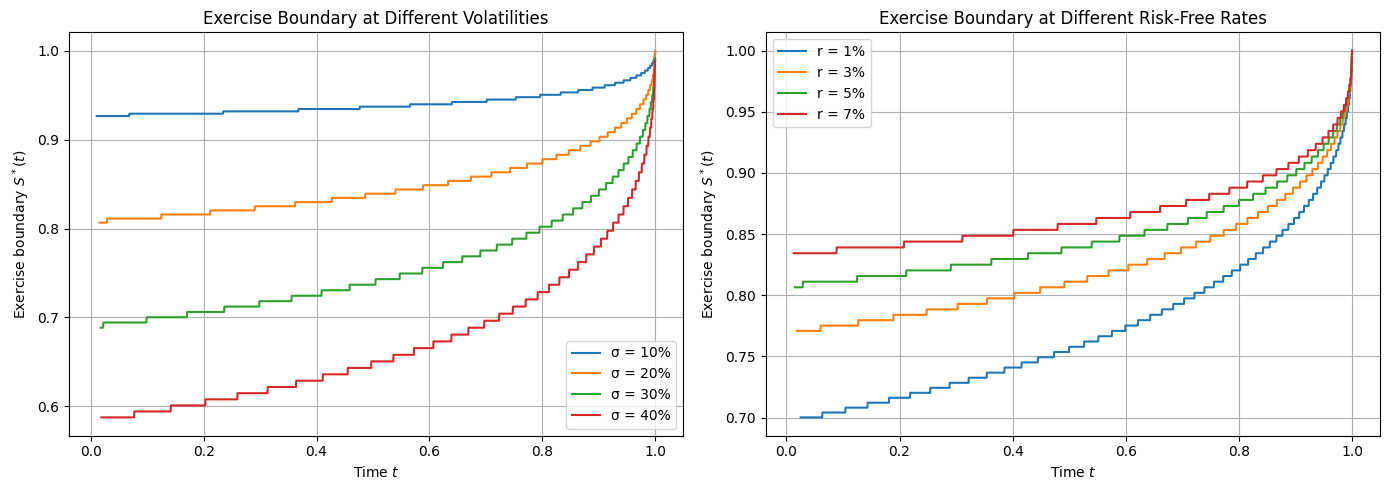

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 1
K = 1
sigma = 0.2
r = 0.05
mu = 0.2
T = 1

def american_put_binomial(S0, K, r, sigma, T, n):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # Risk-neutral probability
    p = (np.exp(r * dt) - d) / (u - d)

    discount = np.exp(-r * dt)
    stock_tree = np.full((n + 1, n + 1), np.nan)
    for i in range(n + 1):
        for j in range(i + 1):
            stock_tree[i, j] = S0 * u**j * d**(i - j)

    option_tree = np.full((n + 1, n + 1), np.nan)
    for j in range(n + 1):
        option_tree[n, j] = max(K - stock_tree[n, j], 0)

    exercise_tree = np.full((n + 1, n + 1), False)
    for j in range(n + 1):
        if stock_tree[n, j] < K:
            exercise_tree[n, j] = True

    # Backward induction
    for i in range(n - 1, -1, -1):
        for j in range(i + 1):
            S = stock_tree[i, j]
            exercise_value = max(K - S, 0)
            continuation_value = discount * (p * option_tree[i + 1, j + 1] + (1 - p) * option_tree[i + 1, j])
            option_tree[i, j] = max(exercise_value, continuation_value)
            exercise_tree[i, j] = (exercise_value >= continuation_value and exercise_value > 0)

    # Extract exercise boundary S*(t)
    times = np.linspace(0, T, n + 1)
    exercise_boundary = np.full(n + 1, np.nan)
    for i in range(n + 1):
        exercised_prices = stock_tree[i, :i + 1][exercise_tree[i, :i + 1]] # first i+1 elements of row i (rest are NaN); selecting only values where early exercise is optimal (exercise_tree[i, :i + 1] is True)
        if len(exercised_prices) > 0:
            exercise_boundary[i] = np.max(exercised_prices)

    option_price = option_tree[0, 0]
    return option_price, times, stock_tree, option_tree, exercise_tree, exercise_boundary

def plot_exercise_boundaries(S0, K, r, sigma_i, T, n):
    sigmas = [0.10, 0.20, 0.30, 0.40]
    rates = [0.01, 0.03, 0.05, 0.07]
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    for sigma_i in sigmas:
        _, times, _, _, _, exercise_boundary = american_put_binomial(S0, K, r, sigma_i, T, n)
        plt.plot(times[::2], exercise_boundary[::2], label=f"σ = {sigma_i:.0%}") #[::2] to plot only even time steps
    plt.xlabel("Time $t$")
    plt.ylabel(r"Exercise boundary $S^*(t)$")
    plt.title("Exercise Boundary at Different Volatilities")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for rate in rates:
        _, times, _, _, _, exercise_boundary = american_put_binomial(S0, K, rate, sigma, T, n)
        plt.plot(times[::2], exercise_boundary[::2], label=f"r = {rate:.0%}")
    plt.xlabel("Time $t$")
    plt.ylabel(r"Exercise boundary $S^*(t)$")
    plt.title("Exercise Boundary at Different Risk-Free Rates")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_exercise_boundaries(S0, K, r, sigma, T, 5000)

Above we see the approximated exercise boundaries for different values of the volatility $σ$ of the underlying asset. As the volatility increases, the exercise boundary is lower, at any point in time. The reason for this phenomenon is that a high volatility is beneficial for the option holder: the option holder captures all the value of potential downward movements in the price of the underlying asset, but does not bear all the cost of the potential upward movements of the underlying asset, since the payout of the put option cannot be lower than zero. Because of this, the option holder requires a lower price of the underlying asset (equivalent to a larger value of the option, and a larger payoff) to exercise the option at any time, leading to a lower exercise boundary.

We also see that the exercise boundary increases as the risk-free interest rate $r$ increases. One reason for this is that a higher interest rate increases the benefit of exercising the option early, since the exercise payoff can subsequently be invested at the risk-free rate. This makes early exercise more attractive and therefore increases the stock price at which the holder chooses to exercise. Another reason is that, under the risk-neutral measure, the drift of the stock is $r$. Thus, an increase in the risk-free rate increases the risk-neutral expected growth rate of the stock price, making future downward movements less likely and reducing the expected value of continuing to hold the option. This makes early exercise  more attractive, further increasing the exercise boundary.

### Price and Exercise Boundary: Longstaff-Schwartz

Another method to estimate the fair price of the option, as well as the exercise boundary, is the Longstaff-Schwartz method: a Monte Carlo simulation-based method, which simulates many possible paths for the underlying asset and uses regression to estimate the continuation value of the option.

To simulate the price path of the underlying asset, we divide the time interval $[0,T]$ into $n$ equally spaced time steps:

$$\Delta t=\frac{T}{n}$$

Under the risk-neutral measure, the underlying asset is follows the geometric Brownian motion SDE

$$dS_t=rS_t\,dt+\sigma S_t\,dW_t^{\mathbb{Q}}$$

The discretization of this process is

$$S_{t+\Delta t}=S_t\exp\left[\left(r-\frac{1}{2}\sigma^2\right)\Delta t+\sigma\sqrt{\Delta t}Z\right]$$

where $Z\sim N(0,1)$. We thus simulate $N$ independent price paths $S_0,S_1,\ldots,S_n$ of the underlying asset, and a large number of paths is used so that the simulated distribution of the underlying asset provides a good approximation of its risk-neutral distribution.

Similarly to for the binomial tree method, the terminal cash flow is

$$C_n=\max(K-S_n,0)$$
if $S_n \lt K$ and $0$ otherwise. We then work backwards through the simulated paths to determine whether exercising before maturity is optimal.


At a given time $t_i$, suppose that a simulated stock price path has  price $S_i$. The value of exercising the put immediately is

$$P_{\text{exercise}}(S_i)=\max(K-S_i,0)$$

The alternative is continuing to hold the option, which has value

$$P_{\text{continue}}(S_i)=\mathbb{E}^\mathbb{Q}\left[e^{-r(T-t_i)}C\mid S_i\right]$$

where $C$ is the future cash flow arising from following the optimal exercise strategy after time $t_i$. In the binomial tree, this expected value is not computed by looking at the value of the option in the nodes in the next time step, but is rather estimated using regression. At each time step, we first identify the simulated paths that are currently in the money - the paths where $S_i < K$ - as there is no reason to exercise an out-of-the-money put (it has a payoff of zero). For these paths, we take the future cash flows generated by the current exercise strategy and discount them back one time step:

$$C_i=C_{i+1}e^{-r\Delta t}$$

The Longstaff-Schwartz method then approximates the conditional expectation

$$E^Q[C_i\mid S_i=S]$$

by polynomial regression of a given degree $d$

$$C_i(S)\approx a_0+a_1S+a_2S^2+\cdots +a_dS^d$$

The estimated polynomial then represents the continuation value as a function of the current stock price. As per usual, the coefficients of the regression are estimated by the OLS (ordinary least squares) method. Once the continuation value is estimated, we compare it with the immediate exercise value at every in-the-money path, and for every simulated path and time step, the algorithm determines whether or not the option should be exercised, based on whether or not the exercise value is higher than the (estimated) continuation value.

If the option is exercised at time $t_i$, the path's future cash flow is the immediate exercise payoff:

$$C_i=K-S_i$$

Otherwise, its future cash flow is discounted one time step:

$$C_i=C_{i+1}e^{-r\Delta t}$$

The algorithm then moves backward one step at a time and repeats the procedure.

The regression also allows us to approximate the exercise boundary: at each time $t_i$, we identify the simulated paths for which exercise is optimal:

$$K-S_i>C_i(S_i)$$

The exercise boundary is then, similarly to with the binomial model, estimated as the highest observed stock price among the paths that are exercised:

$$S^*(t_i)\approx\max\left\{S_i:K-S_i>C_i(S_i)\right\}$$

After the backward induction has been completed, every simulated path has an associated exercise time and corresponding payoff. The fair price of the option is then calculated as the average value, of all price paths, at the first node.

Below, the estimate exercise boundary is plotted for the binomial tree method as well as for the Longstaff-Schwartz method.

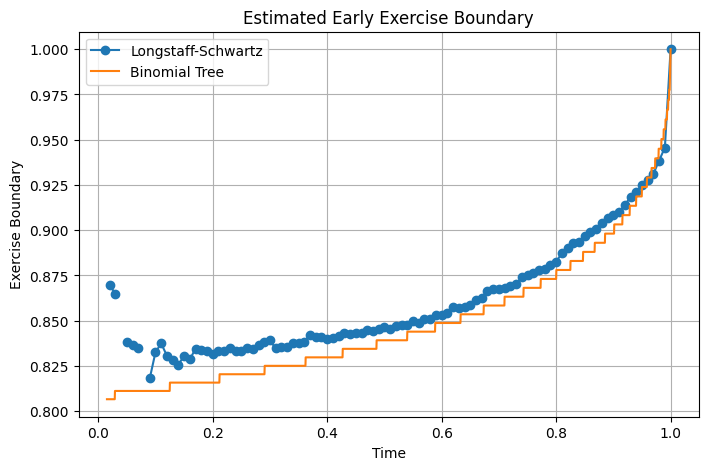

In [ ]:
import numpy as np
np.random.seed(1)
S0 = 1
K = 1
sigma = 0.2
r = 0.05
mu = 0.2
T = 1

def longstaff_schwartz_american_put(S0, K, sigma, r, T, N, n, degree=4):
    dt = T / n
    time_grid = np.linspace(0, T, n + 1)
    Z = np.random.normal(size=(N, n))

    paths = np.zeros((N, n + 1))
    paths[:, 0] = S0
    for i in range(n):
        paths[:, i + 1] = (paths[:, i] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, i]))

    cashflows = np.maximum(K - paths[:, -1], 0)
    exercise_times = np.full(N, T)
    exercised = paths[:, -1] < K
    exercise_times[exercised] = T
    exercise_boundary = np.full(n + 1, np.nan)
    exercise_boundary[-1] = K

    for i in range(n - 1, 0, -1):
        S = paths[:, i]
        immediate_payoff = np.maximum(K - S, 0)
        itm = immediate_payoff > 0
        if np.sum(itm) == 0:
            continue
        discounted_cashflows = cashflows * np.exp(-r * dt)

        # Regression (x=stock price, y=discounted cash flow)
        regression = np.polyfit(S[itm], discounted_cashflows[itm], degree)
        continuation_value = np.polyval(regression, S[itm])

        # Determine whether to exercise
        exercise = immediate_payoff[itm] > continuation_value

        itm_indices = np.where(itm)[0] # Indices of paths that are in the money
        exercise_indices = itm_indices[exercise]

        # Record exercise boundary
        if len(exercise_indices) > 0:
            exercise_boundary[i] = np.max(paths[exercise_indices, i])

        # Update cashflows for paths that exercise now
        cashflows[exercise_indices] = (immediate_payoff[exercise_indices])
        exercise_times[exercise_indices] = time_grid[i]

        # Paths that do not exercise keep their existing future cashflow, discounted one step
        continue_indices = itm_indices[~exercise]
        cashflows[continue_indices] = (cashflows[continue_indices] * np.exp(-r * dt))

        # Out-of-the-money paths simply continue
        otm = ~itm
        cashflows[otm] = cashflows[otm] * np.exp(-r * dt)

    price = np.mean(cashflows) * np.exp(-r * dt * 0)
    return price, paths, exercise_times, exercise_boundary

def plot_exercise_boundaries(exercise_boundary_ls, exercise_boundary_binomial):
    time_grid_ls = np.linspace(0, T, len(exercise_boundary_ls))
    time_grid_binomial = np.linspace(0, T, len(exercise_boundary_binomial))

    plt.figure(figsize=(8, 5))
    plt.plot(time_grid_ls, exercise_boundary_ls, marker='o', label="Longstaff-Schwartz")
    plt.plot(time_grid_binomial[::2], exercise_boundary_binomial[::2], label="Binomial Tree")
    plt.xlabel("Time")
    plt.ylabel("Exercise Boundary")
    plt.title("Estimated Early Exercise Boundary")
    plt.legend()
    plt.grid(True)
    plt.show()

_, _, _, exercise_boundary_ls = longstaff_schwartz_american_put(S0, K, sigma, r, T, 1000000, 100)
_, _, _, _, _, exercise_boundary_binomial = american_put_binomial(S0, K, r, sigma, T, 5000)
plot_exercise_boundaries(exercise_boundary_ls, exercise_boundary_binomial)


Above we see that the binomial model and the Longstaff-Schwartz model result in relatively similar exercise boundaries. As the number of time steps used in the binomial model is increased, the two methods converge even more. In the Longstaff-Schwartz exercise boundary, the first few points do not follow the trend of the later points. The reason for this is that, for the first few time steps, the prices of the underlying stock have not had much time to evolve from the original price, so there are very few stock paths that have reached the point where early exercise is optimal. Consequently, for these time steps, there is not much data to base the estimate of the exercise boundary on, creating a strange appearance in the bottom left of the plot above.
### Price and Exercise Boundary: The Barone-Adesi-Whaley Approximation
Beside the binomial model and the Longstaff-Schwartz methods of estimating the price and exercise boundary for the American put option, another method is the Barone-Adesi-Whaley (BAW) method, which approximates the price of the option by dividing it into the corresponding European put price plus an early-exercise premium.

The BAW approximation for the American put option price $P_A$ given the corresponding European put option price $P_E$ is given by

$$P_A(S_0, τ, K) = \begin{cases} P_E(S_0, τ, K) + A\left(\frac{S_0}{S^*}\right)^\gamma & S_0 > S^* \\ K - S_0 & S_0 \le S^* \end{cases} $$

where $τ$ is the time to maturity,

$$\gamma = \frac{1}{2}\left(1 - \sqrt{1 + \frac{8r}{(1 - e^{-rτ})\sigma^2}}\right)$$

$$A = -\frac{S^*}{\gamma}\left(1 - e^{-rτ}\Phi[-d_1(S^*)]\right)$$

$$d_1(S) = \frac{\ln(S/K) + (r+\frac{\sigma^2}{2})τ}{\sigma\sqrt{τ}}.$$


The variable $S^*$ is the exercise boundary. A closed form solution for $S^*$ does not exist, but it can be computed numerically by solving

$$K - S^* = P_E(S^*, τ, K) - \left(1 - e^{-rτ}\text{N}[-d_1(S^*)]\right)\frac{S^*}{\gamma}$$

We begin by numerically solving for the exercise boundary, and then estimate the price of the American put option using this.

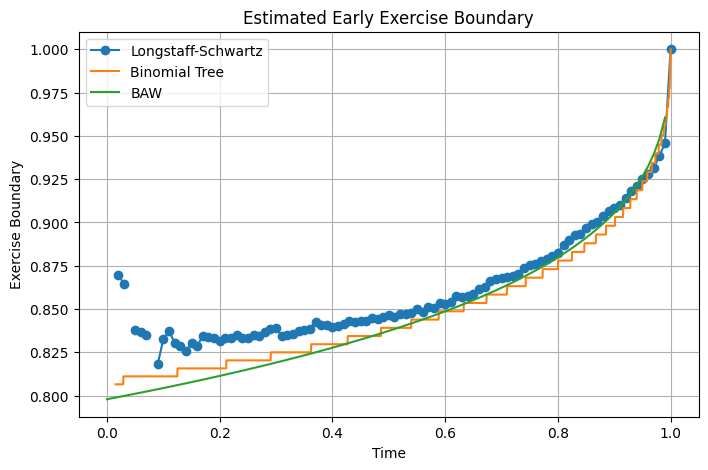

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

S0 = 1
K = 1
sigma = 0.2
r = 0.05
mu = 0.2
T = 1

def european_put_price(S, T, K, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def d1(S, T, K, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


def gamma(T, r, sigma):
    return 0.5 * (1 - np.sqrt(1 + 8 * r / ((1 - np.exp(-r * T)) * sigma**2)))


def baw_boundary_equation(S_star, T, K, r, sigma):
    g = gamma(T, r, sigma)
    d1_star = d1(S_star, T, K, sigma)
    pe = european_put_price(S_star, T, K, r, sigma)

    rhs = pe - (1 - np.exp(-r * T) * norm.cdf(-d1_star)) * S_star / g
    return K - S_star - rhs


def baw_exercise_boundary(T, K, r, sigma):
    # For a put, S* lies below K. We search for a sign change on (0, K)
    S_low = 1e-12
    S_high = K * (1 - 1e-12)
    return brentq(baw_boundary_equation, S_low, S_high, args=(T, K, r, sigma))


def plot_exercise_boundaries(T_max, K, r, sigma, exercise_boundary_ls, exercise_boundary_binomial, n):
    # Avoid T = 0 because the BAW formulas contain sqrt(T) and (1 - exp(-rT)) in the denominator.
    T_values = np.linspace(T_max, T_max / n, n)

    S_star_values = np.array([baw_exercise_boundary(T, K, r, sigma) for T in T_values])

    # Convert BAW time-to-maturity values to calendar time
    t_values_baw = T_max - T_values

    # Time grids for LS and binomial boundaries
    time_grid_ls = np.linspace(0, T_max, len(exercise_boundary_ls))
    time_grid_binomial = np.linspace(0, T_max, len(exercise_boundary_binomial))

    plt.figure(figsize=(8, 5))

    # Longstaff-Schwartz
    plt.plot(time_grid_ls, exercise_boundary_ls, marker='o', label="Longstaff-Schwartz")

    # Binomial Tree
    plt.plot(time_grid_binomial[::2], exercise_boundary_binomial[::2], label="Binomial Tree")

    # BAW
    plt.plot(t_values_baw, S_star_values, label="BAW")

    plt.xlabel("Time")
    plt.ylabel("Exercise Boundary")
    plt.title("Estimated Early Exercise Boundary")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_exercise_boundaries(1, K, r, sigma, exercise_boundary_ls, exercise_boundary_binomial, 100)

In the figure above, we see that the BAW approximation for the exercise boundary of the American put gives similar results to the two previous methods, suggesting all three methods likely give good approximations of the true exercise boundary. Below, we compare the approximations of the fair price of the American option for the three different methods, and show ow the price estimated by each methods depends on the volatility $σ$.


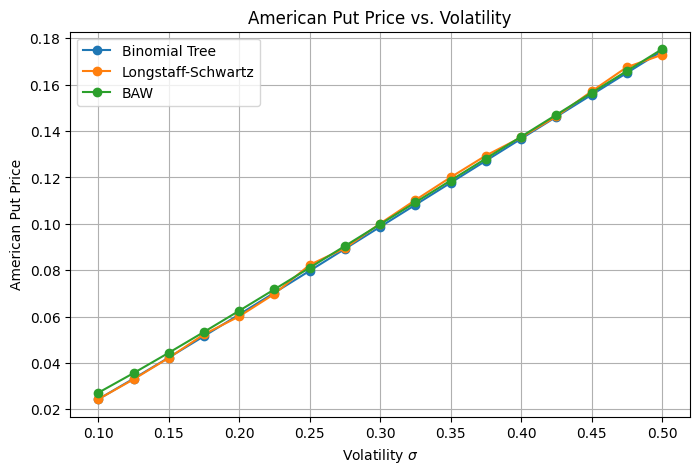

In [ ]:
def baw_american_put_price(S0, T, K, r, sigma):
    S_star = baw_exercise_boundary(T, K, r, sigma)
    if S0 <= S_star:
        return K - S0

    g = gamma(T, r, sigma)
    d1_star = d1(S_star, T, K, sigma)
    A = -S_star / g * (1 - np.exp(-r * T) * norm.cdf(-d1_star))
    pe = european_put_price(S0, T, K, r, sigma)

    return pe + A * (S0 / S_star)**g

def plot_price_vs_volatility(S0, K, r, T, N_binomial, N_ls, n_ls, sigma_values):
    binomial_prices = []
    ls_prices = []
    baw_prices = []

    for sigma in sigma_values:
        price, _, _, _, _, _ = american_put_binomial(S0, K, r, sigma, T, N_binomial)
        binomial_prices.append(price)

        price, _, _, _ = longstaff_schwartz_american_put(S0, K, sigma, r, T, N_ls, n_ls)
        ls_prices.append(price)

        price = baw_american_put_price(S0, T, K, r, sigma)
        baw_prices.append(price)

    plt.figure(figsize=(8, 5))

    plt.plot(sigma_values, binomial_prices, marker='o', label="Binomial Tree")
    plt.plot(sigma_values, ls_prices, marker='o', label="Longstaff-Schwartz")
    plt.plot(sigma_values, baw_prices, marker='o', label="BAW")
    plt.xlabel(r"Volatility $\sigma$")
    plt.ylabel("American Put Price")
    plt.title("American Put Price vs. Volatility")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_price_vs_volatility(S0, K, r, T, 5000, 10000, 100, np.linspace(0.10, 0.50, 17))

In the figure above, we see that, like for the exercise boundary, the three methods give similar results for the fair price of the option, at varying values of the volatility. Like the exercise boundary, then, it is reasonable to assume that the results of the three methods is close to the true fair value of the option.



